In [ ]:
from pathlib import Path
import pandas as pd
import sys, math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.transform import StandardScaler
from sklearn.impute import SimpleImputer

# Ajout du chemin du dossier src au sys.path
src_path = Path("../src").resolve()
if src_path not in sys.path:
    sys.path.append(str(src_path))

# Importation des modules nécessaires
from analysis_utils import top_correlated_features, plot_numeric_histograms, plot_missing_bar 
from cleaning_utils import get_missing_summary,  get_special_columns

## Liens pour télécharger le jeu de donnéee et la description

- [Dataset](https://drive.google.com/file/d/1C-tYJcgJDx5AuF7_oz7U4bbY0PERiFLo/view?usp=sharing)
- [Description](https://drive.google.com/file/d/1VSRPKK6ys0Kn3gSYDHgrQogdBAHXcEKg/view?usp=sharing)

## Définitions des Chemins

In [3]:
ROOT = (Path.cwd().parent).resolve()
# Ajouter le dossier 'src' au chemin de recherche des modules
src_path = ROOT / "src"
sys.path.append(str(src_path))

# DATA = (Path(__file__).parent / "df"/ "water_portability.csv").resolve()
# Path.cwd() cible le dossier racine où tourne ton notebook
DATA = (Path.cwd().parent / "data" / "water_potability.csv").resolve()

if DATA.exists():
    print(f"✅ Fichier trouvé ! Chemin : {DATA}")
else:
    print(f"❌ Erreur : Le fichier n'existe pas à l'emplacement {DATA}")

✅ Fichier trouvé ! Chemin : /home/coule/Documents/projets/waterflow/data/water_potability.csv


In [4]:
df = pd.read_csv(DATA)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## Définition de la target et de features

In [6]:
TARGET = "Potability"
FEATURES = [col for col in df.columns if col != TARGET]

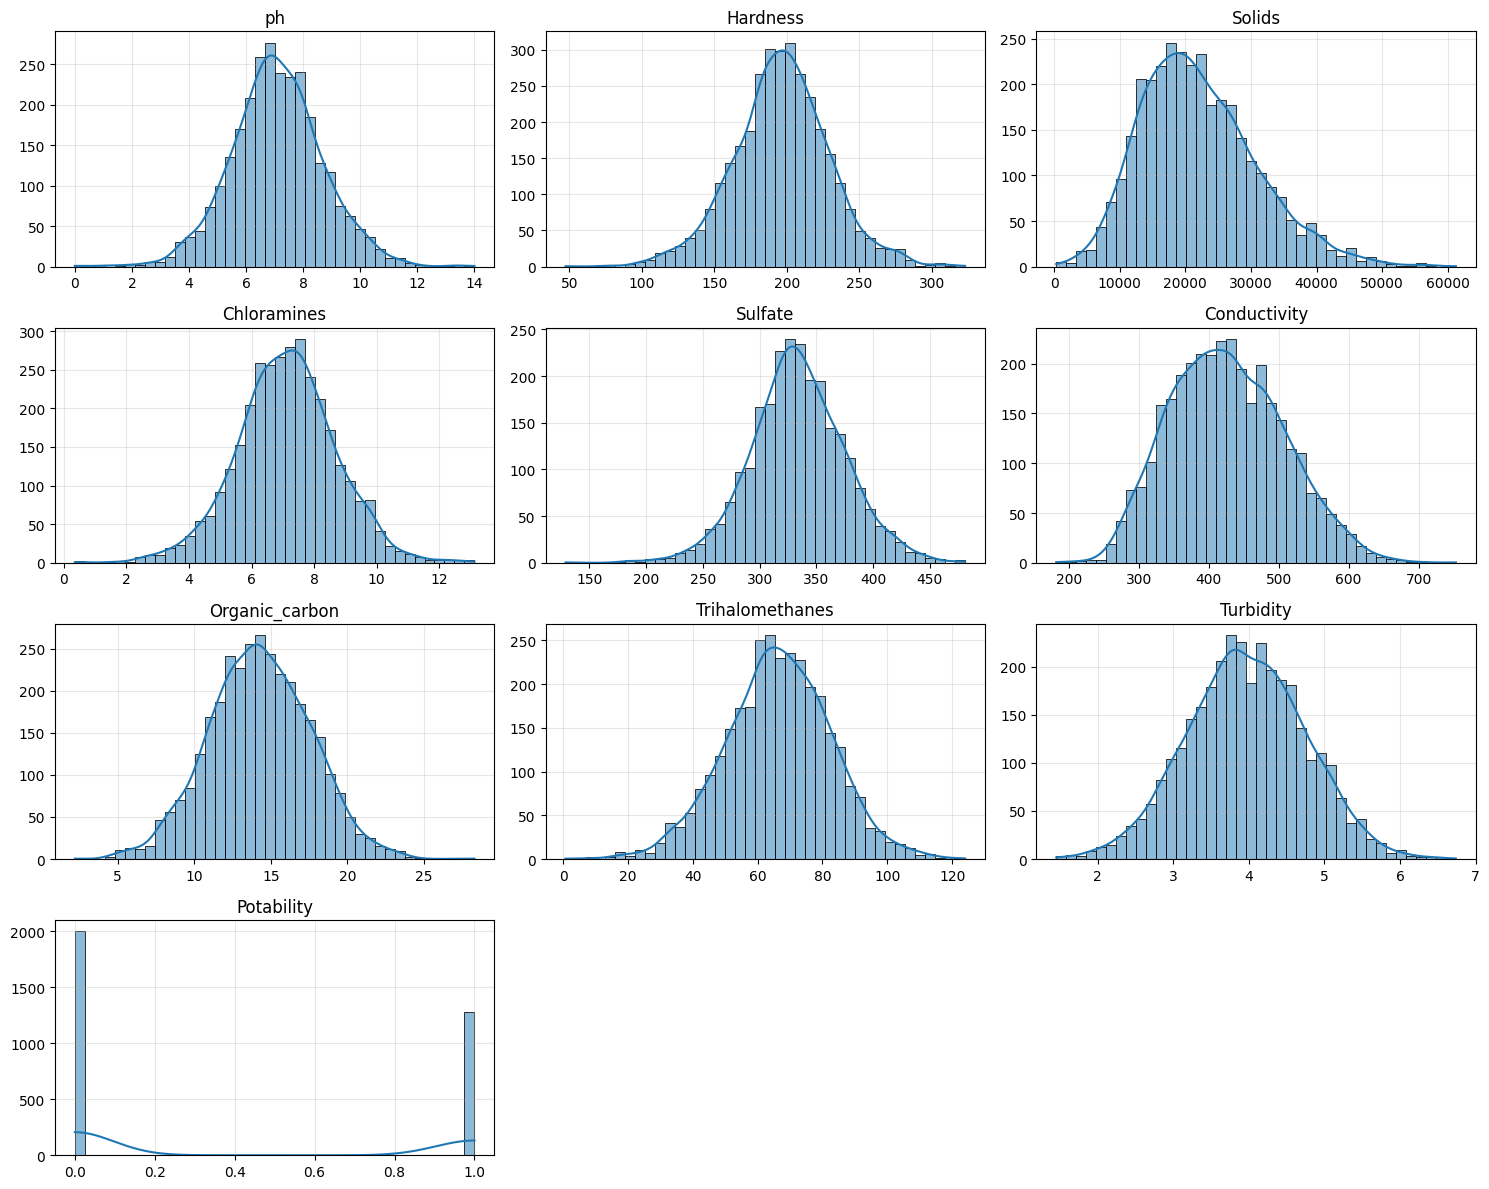

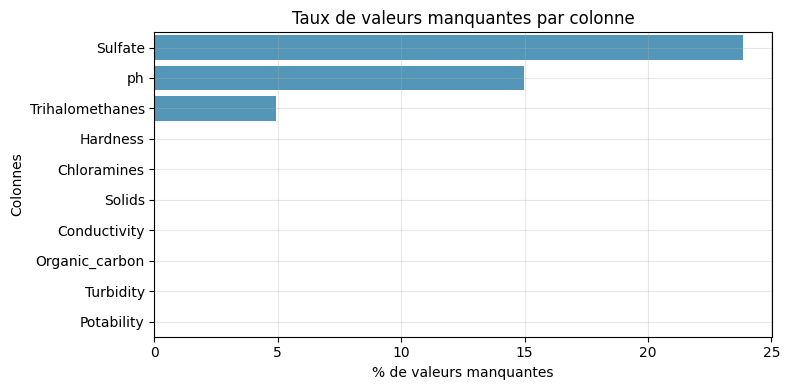

In [5]:
# 1. Chargement et Exploration Initiale (EDA)
missing_info = get_missing_summary(df)
special_cols = get_special_columns(df)

# Visualisations rapides
plot_numeric_histograms(df)
plot_missing_bar(df)

/tmp/ipykernel_18441/510683507.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")


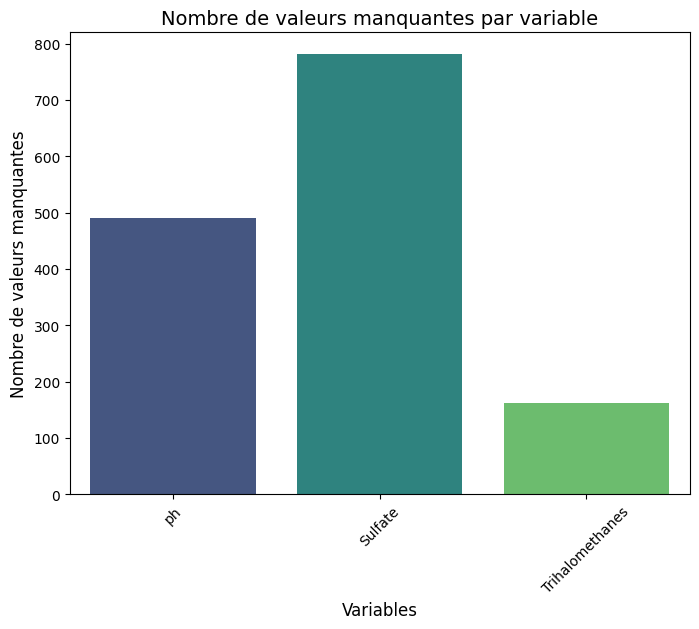

In [8]:
# Visualisation des valeurs manquantes pour les trois variables

# Calcul des valeurs manquantes
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

# Barplot des valeurs manquantes
plt.figure(figsize=(8, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")
plt.title("Nombre de valeurs manquantes par variable", fontsize=14)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Nombre de valeurs manquantes", fontsize=12)
plt.xticks(rotation=45)
plt.show()

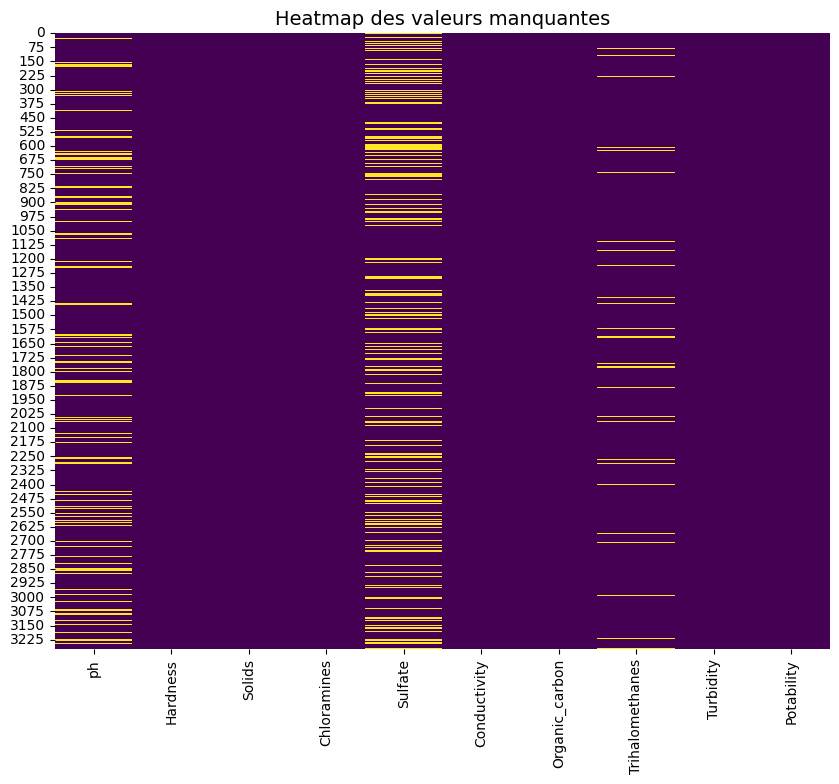

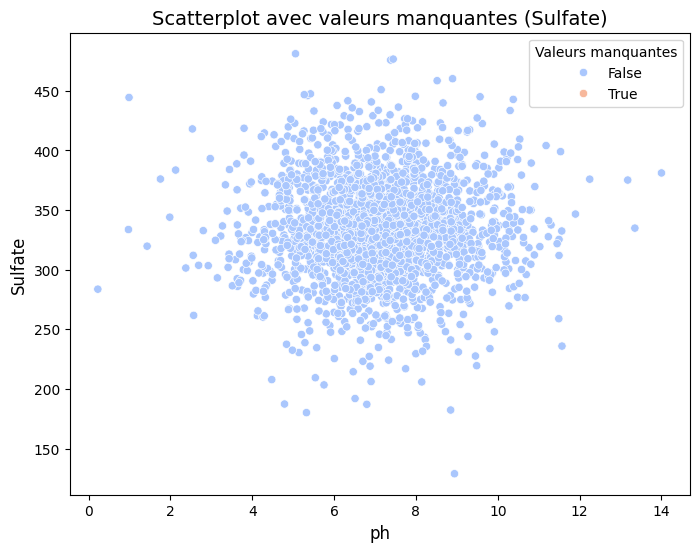

/tmp/ipykernel_18441/2523915012.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df["Sulfate"].isnull(), y="Conductivity", palette="Set2")


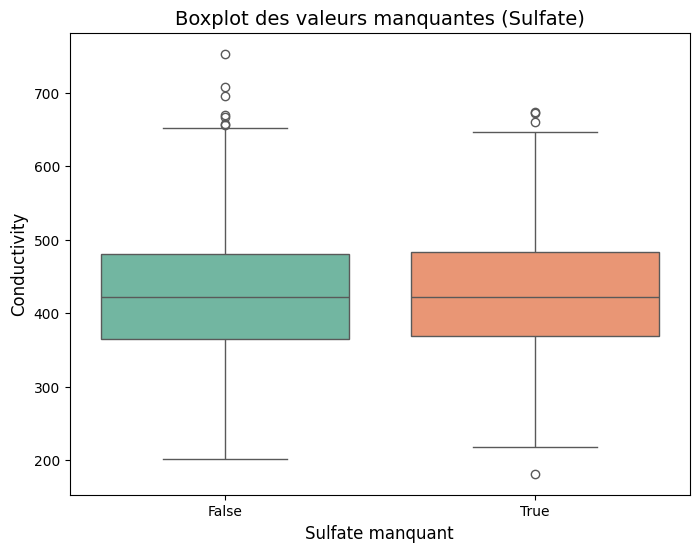

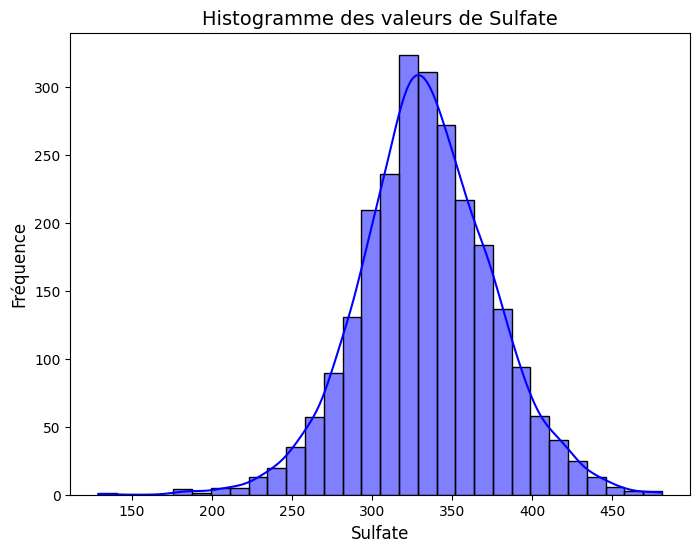

In [9]:
# Heatmap des valeurs manquantes
plt.figure(figsize=(10, 8))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap des valeurs manquantes", fontsize=14)
plt.show()

# Scatterplot avec indicateurs de valeurs manquantes
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="ph", y="Sulfate", hue=df["Sulfate"].isnull(), palette="coolwarm")
plt.title("Scatterplot avec valeurs manquantes (Sulfate)", fontsize=14)
plt.xlabel("ph", fontsize=12)
plt.ylabel("Sulfate", fontsize=12)
plt.legend(title="Valeurs manquantes")
plt.show()

# Boxplot des valeurs manquantes
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x=df["Sulfate"].isnull(), y="Conductivity", palette="Set2")
plt.title("Boxplot des valeurs manquantes (Sulfate)", fontsize=14)
plt.xlabel("Sulfate manquant", fontsize=12)
plt.ylabel("Conductivity", fontsize=12)
plt.show()

# Histogramme des valeurs manquantes
plt.figure(figsize=(8, 6))
sns.histplot(df["Sulfate"], kde=True, color="blue", bins=30)
plt.title("Histogramme des valeurs de Sulfate", fontsize=14)
plt.xlabel("Sulfate", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.show()

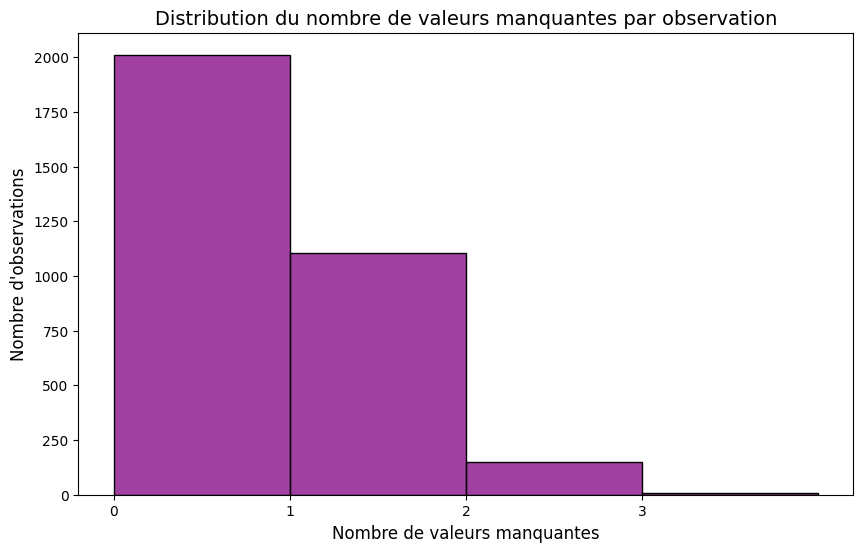

In [10]:
# Analyse des observations avec plusieurs valeurs manquantes
plt.figure(figsize=(10, 6))
df['missing_count'] = df.isnull().sum(axis=1)
sns.histplot(df['missing_count'], bins=range(0, df['missing_count'].max() + 2), kde=False, color="purple")
plt.title("Distribution du nombre de valeurs manquantes par observation", fontsize=14)
plt.xlabel("Nombre de valeurs manquantes", fontsize=12)
plt.ylabel("Nombre d'observations", fontsize=12)
plt.xticks(range(0, df['missing_count'].max() + 1))
plt.show()

# Suppression de la colonne temporaire
df.drop(columns=['missing_count'], inplace=True)

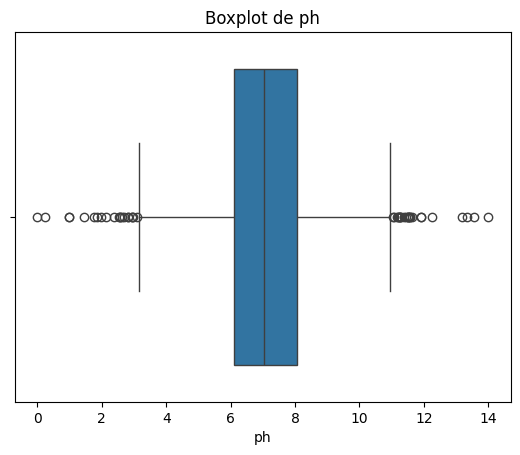

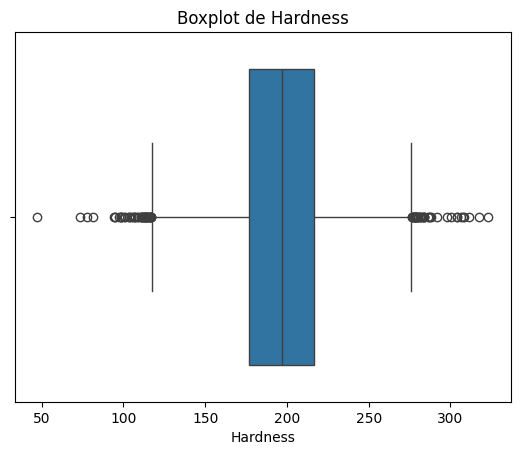

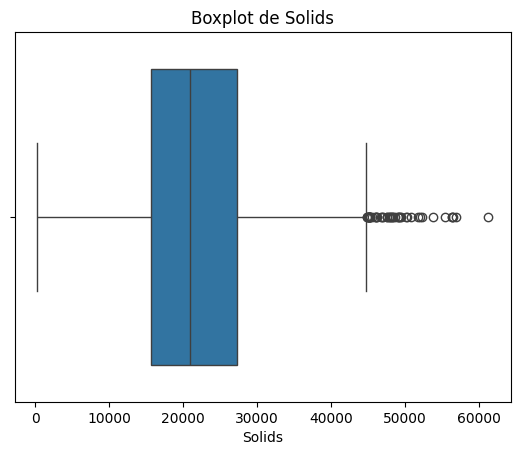

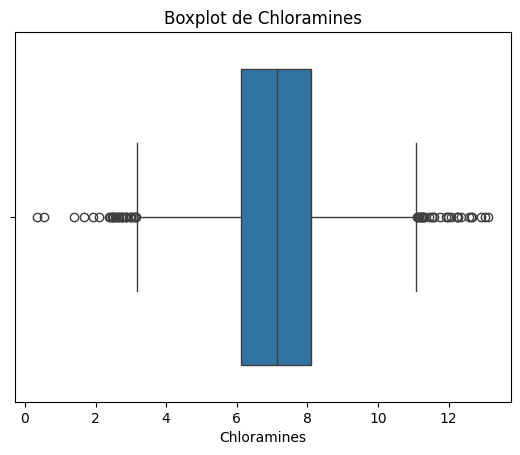

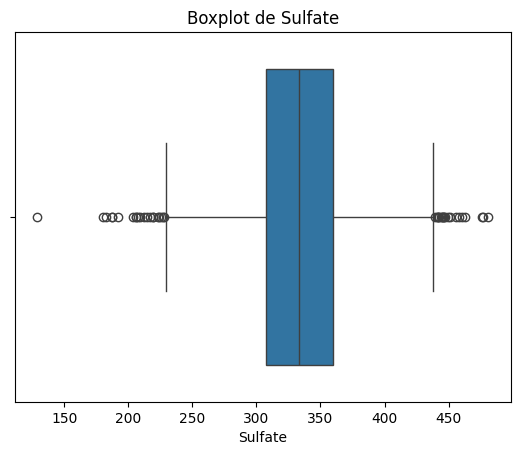

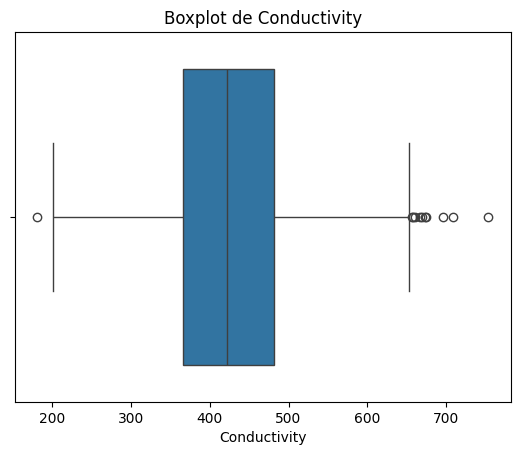

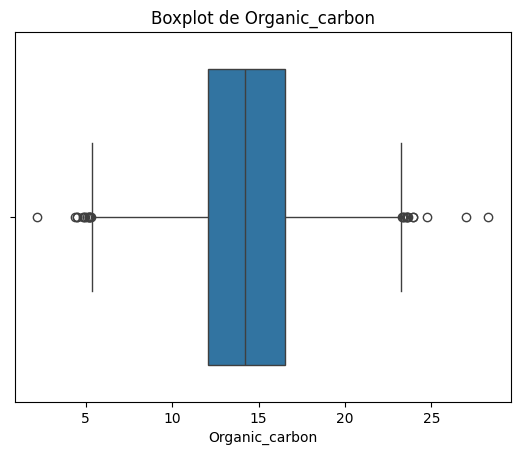

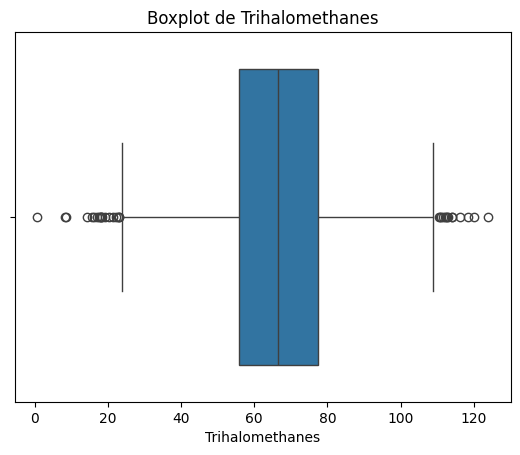

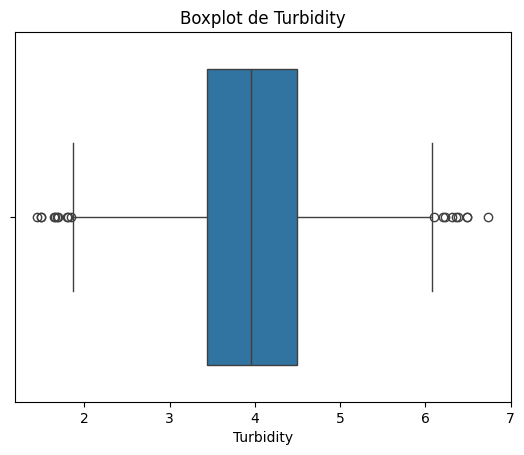

In [14]:
for col in FEATURES:
    boxplot = sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [19]:
top_correlated_features(df[FEATURES], df[TARGET], 9)



(ph                -0.003556
 Hardness          -0.013837
 Solids             0.033743
 Chloramines        0.023779
 Sulfate           -0.023577
 Conductivity      -0.008128
 Organic_carbon    -0.030001
 Trihalomethanes    0.007130
 Turbidity          0.001581
 Name: target, dtype: float64,
 ['Solids',
  'Organic_carbon',
  'Chloramines',
  'Sulfate',
  'Hardness',
  'Conductivity',
  'Trihalomethanes',
  'ph',
  'Turbidity'])

In [ ]:
imputer = SimpleImputer(missing_values=p.nan, strategy='mean')

NameError: name 'simpleImputer' is not defined

In [ ]:
StandardScaler